In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import os

file_path = "Data R.xls"

output_dir = "processed_data"
plots_dir = os.path.join(output_dir, "plots")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sheets_map = {
    "ammonia": "ammonia",
    "ethanol": "ethanol",
    "acetone": "acetone",
    "toluol": "toluol"
}

for gas_name, sheet_name in sheets_map.items():

    print(f"Processing {gas_name}...")

    df = pd.read_excel(file_path, sheet_name=sheet_name, engine="xlrd", header=None)

    ug_row = df.iloc[-1, 2:]
    Ug = pd.to_numeric(ug_row, errors='coerce').values

    Ug_mask = ~np.isnan(Ug)
    Ug = Ug[Ug_mask]

    n_rows = df.shape[0] - 1   # last row is Ug

    C = pd.to_numeric(df.iloc[:n_rows, 0], errors='coerce').values

    R_matrix = df.iloc[:n_rows, 2:].apply(pd.to_numeric, errors='coerce').values

    R_matrix = R_matrix[:, Ug_mask]

    mask_C = ~np.isnan(C)
    C = C[mask_C]
    R_matrix = R_matrix[mask_C, :]

    C_all, Ug_all, R_all = [], [], []

    for i, c in enumerate(C):
        for j, ug in enumerate(Ug):
            val = R_matrix[i, j]

            if (
                not np.isnan(val)
                and not np.isnan(c)
                and not np.isnan(ug)
            ):
                C_all.append(c)
                Ug_all.append(ug)
                R_all.append(val)

    C_all = np.array(C_all)
    Ug_all = np.array(Ug_all)
    R_all = np.array(R_all)

    C_new = np.arange(np.nanmin(C_all), np.nanmax(C_all), 0.1)
    Ug_new = np.arange(0, 1.5 + 0.05, 0.05)

    C_grid, Ug_grid = np.meshgrid(C_new, Ug_new)

    points = np.column_stack((C_all, Ug_all))
    R_grid = griddata(points, R_all, (C_grid, Ug_grid), method='linear')

    C_new = np.round(C_new, 1)
    Ug_new = np.round(Ug_new, 2)
    R_grid = np.round(R_grid, 5)

    result_df = pd.DataFrame(
        R_grid.T,
        index=C_new,
        columns=Ug_new
    )

    result_df.index.name = "C, % \ Ug, V"

    output_path = os.path.join(output_dir, f"{gas_name}.csv")
    result_df.to_csv(output_path)

print("DONE. All gases processed successfully.")

Processing ammonia...
Processing ethanol...
Processing acetone...
Processing toluol...
DONE. All gases processed successfully.


Processing ethanol...


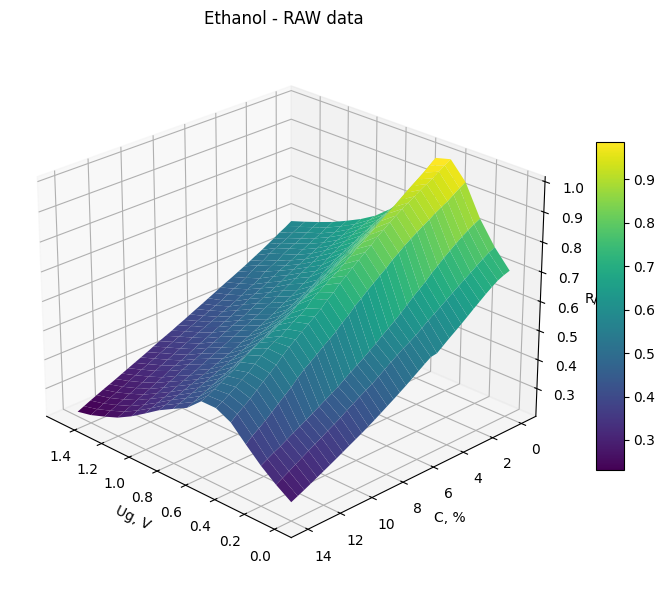

Processing ammonia...


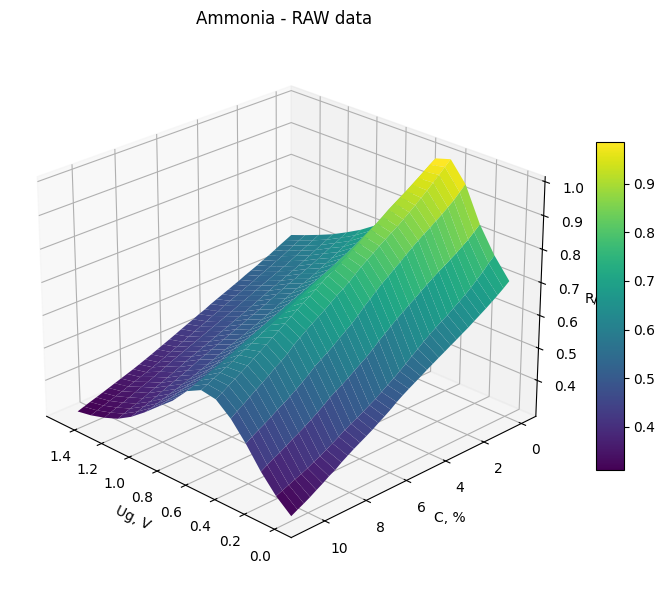

Processing acetone...


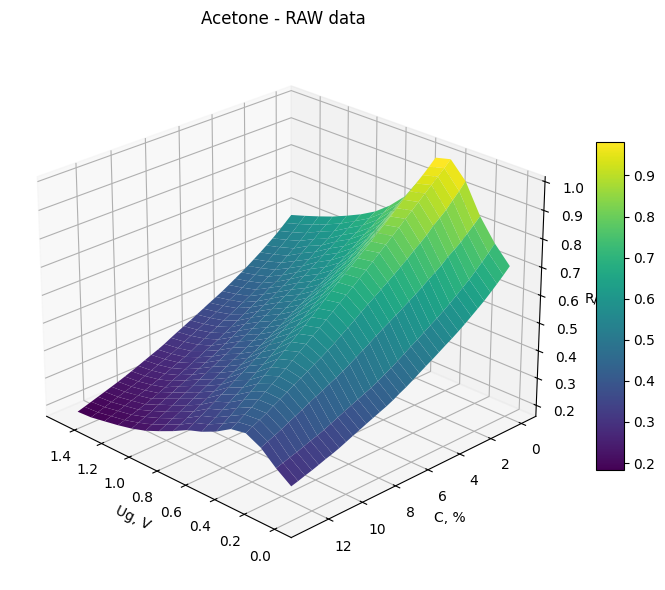

Processing toluol...


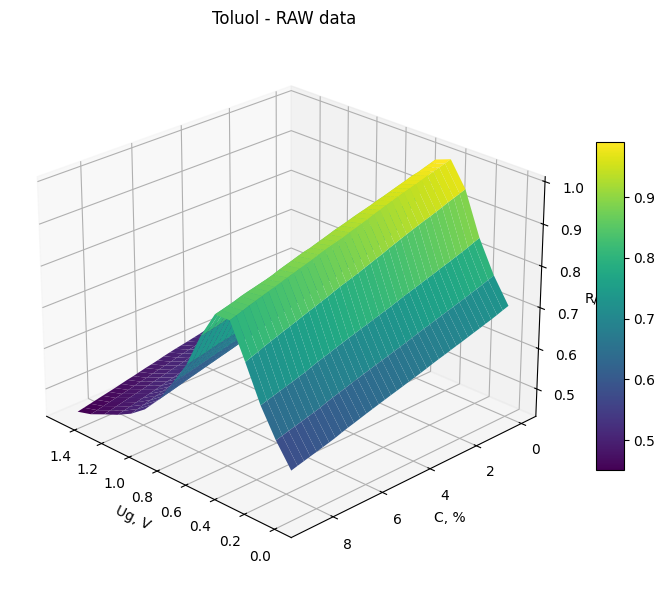

DONE. All RAW plots saved.


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

file_path = "Data R.xls"

output_dir = os.path.join("processed_data", "plots")
os.makedirs(output_dir, exist_ok=True)

sheets = ["ethanol","ammonia", "acetone", "toluol"]

for sheet_name in sheets:

    print(f"Processing {sheet_name}...")

    df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        engine="xlrd",
        header=None
    )

    ug_row = df.iloc[-1, 2:]

    Ug = pd.to_numeric(
        ug_row,
        errors="coerce"
    ).values

    Ug_mask = ~np.isnan(Ug)
    Ug = Ug[Ug_mask]

    C = pd.to_numeric(
        df.iloc[:-1, 0],
        errors="coerce"
    ).values

    mask_C = ~np.isnan(C)
    C = C[mask_C]

    R_matrix = df.iloc[:-1, 2:] \
        .apply(pd.to_numeric, errors="coerce") \
        .values

    R_matrix = R_matrix[:, Ug_mask]
    R_matrix = R_matrix[mask_C, :]

    X, Y = np.meshgrid(Ug, C)

    Z = R_matrix

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection='3d')

    surface = ax.plot_surface(
        X,
        Y,
        Z,
        cmap='viridis',
        edgecolor='none'
    )

    ax.set_title(f"{sheet_name.capitalize()} - RAW data")
    ax.set_xlabel("Ug, V")
    ax.set_ylabel("C, %")
    ax.set_zlabel("R/R0")

    ax.view_init(elev=25, azim=135)

    fig.colorbar(surface, shrink=0.6, aspect=12)

    plt.tight_layout()

    output_path = os.path.join(
        output_dir,
        f"{sheet_name}_raw.png"
    )

    plt.savefig(output_path, dpi=300)

    plt.show()

print("DONE. All RAW plots saved.")

Processing ethanol.csv...


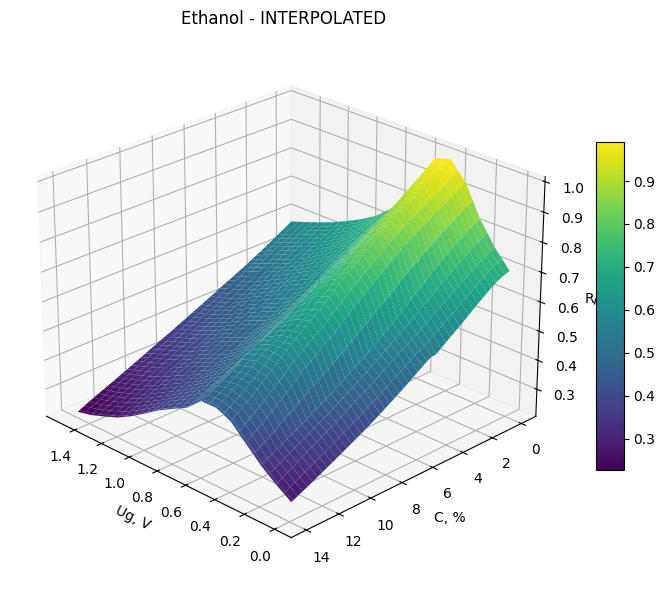

Processing ammonia.csv...


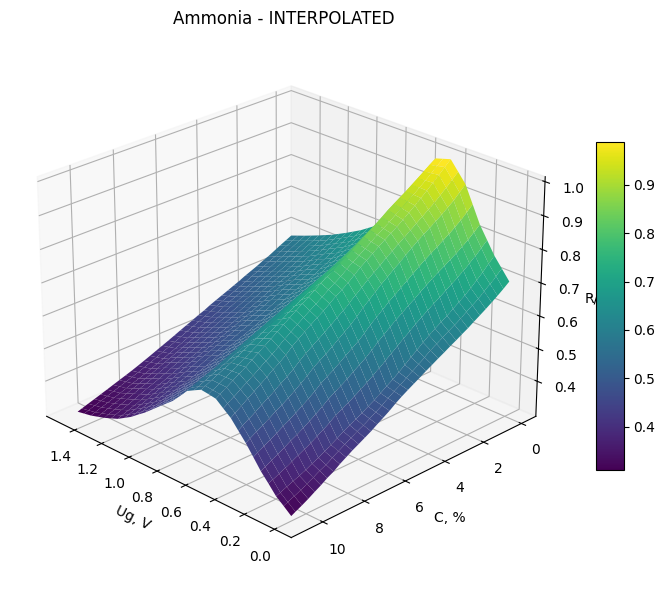

Processing acetone.csv...


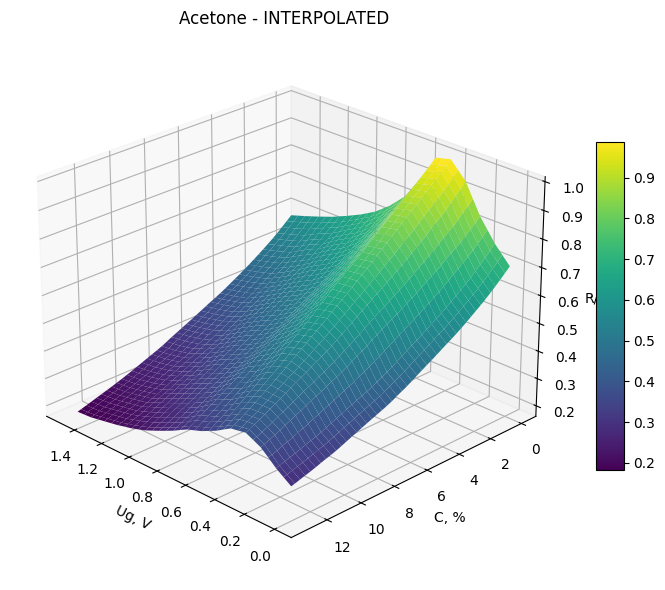

Processing toluol.csv...


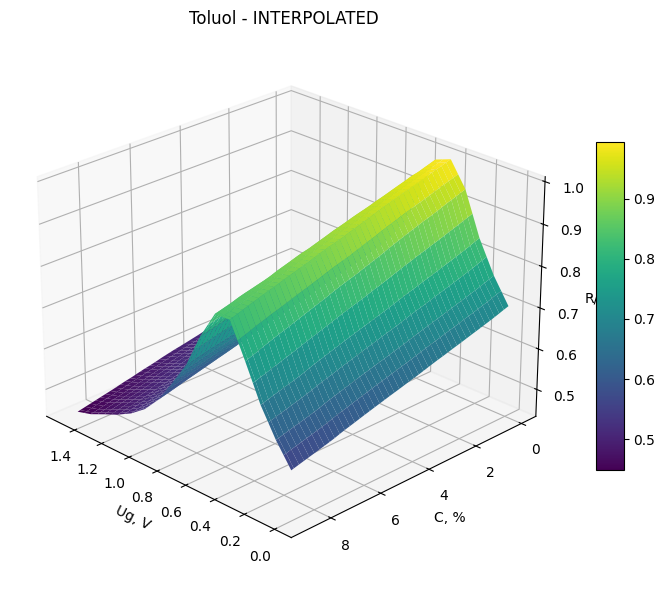

DONE. All INTERPOLATED plots saved.


In [3]:
input_folder = "processed_data"

output_dir = os.path.join("processed_data", "plots")
os.makedirs(output_dir, exist_ok=True)

files = [
    "ethanol.csv",
    "ammonia.csv",
    "acetone.csv",
    "toluol.csv"
]

for file in files:

    print(f"Processing {file}...")

    path = os.path.join(input_folder, file)

    df = pd.read_csv(path, index_col=0)

    C = df.index.astype(float).values
    Ug = df.columns.astype(float).values

    X, Y = np.meshgrid(Ug, C)

    Z = df.values

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection='3d')

    surface = ax.plot_surface(
        X,
        Y,
        Z,
        cmap='viridis',
        edgecolor='none'
    )

    ax.set_title(
        f"{file.replace('.csv','').capitalize()} - INTERPOLATED"
    )

    ax.set_xlabel("Ug, V")
    ax.set_ylabel("C, %")
    ax.set_zlabel("R/R0")

    ax.view_init(elev=25, azim=135)

    fig.colorbar(surface, shrink=0.6, aspect=12)

    plt.tight_layout()

    output_path = os.path.join(
        output_dir,
        file.replace(".csv", "_interpolated.png")
    )

    plt.savefig(output_path, dpi=300)

    plt.show()

print("DONE. All INTERPOLATED plots saved.")

Processing ethanol...
Processing ammonia...
Processing acetone...
Processing toluol...
Interpolation complete.


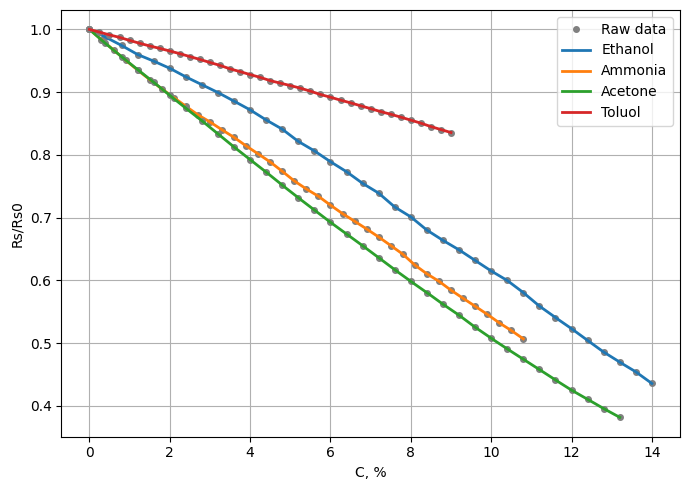

DONE. All add-data processed.


In [4]:
from scipy.interpolate import interp1d

file_path = "Data R.xls"
sheet_name = "add-data"

output_dir = "processed_data"
plots_dir = os.path.join(output_dir, "plots")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

df = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    engine="xlrd"
)

gases = {
    "ethanol": ("Ethanol C (%)", "Ethanol R/R0"),
    "ammonia": ("Ammonia C (%)", "Ammonia R/R0"),
    "acetone": ("Acetone C (%)", "Acetone R/R0"),
    "toluol": ("Toluol C (%)", "Toluol R/R0")
}

colors = {
    "ethanol": "tab:blue",
    "ammonia": "tab:orange",
    "acetone": "tab:green",
    "toluol": "tab:red"
}

for gas_name, (c_col, r_col) in gases.items():

    print(f"Processing {gas_name}...")

    C = pd.to_numeric(df[c_col], errors="coerce").values
    R = pd.to_numeric(df[r_col], errors="coerce").values

    mask = (~np.isnan(C)) & (~np.isnan(R))

    C = C[mask]
    R = R[mask]

    C_new = np.arange(
        np.min(C),
        np.max(C),
        0.1
    )

    C_new = np.append(C_new, np.max(C))

    interpolator = interp1d(
        C,
        R,
        kind="linear"
    )

    R_new = interpolator(C_new)

    C_new = np.round(C_new, 2)
    R_new = np.round(R_new, 5)

    result_df = pd.DataFrame({
        "C, %": C_new,
        "Rs/Rs0": R_new
    })

    output_csv = os.path.join(
        output_dir,
        f"{gas_name}_add.csv"
    )

    result_df.to_csv(output_csv, index=False)

print("Interpolation complete.")

plt.figure(figsize=(7, 5))

raw_label_added = False

for gas_name, (c_col, r_col) in gases.items():

    C = pd.to_numeric(df[c_col], errors="coerce").values
    R = pd.to_numeric(df[r_col], errors="coerce").values

    mask = (~np.isnan(C)) & (~np.isnan(R))

    C = C[mask]
    R = R[mask]

    plt.plot(
        C,
        R,
        "o",
        color="gray",
        markersize=4,
        label="Raw data" if not raw_label_added else None
    )

    raw_label_added = True

    csv_path = os.path.join(
        output_dir,
        f"{gas_name}_add.csv"
    )

    gas_df = pd.read_csv(csv_path)

    plt.plot(
        gas_df["C, %"],
        gas_df["Rs/Rs0"],
        "-",
        color=colors[gas_name],
        linewidth=2,
        label=gas_name.capitalize()
    )

plt.xlabel("C, %")
plt.ylabel("Rs/Rs0")

plt.legend()
plt.grid(True)

plt.tight_layout()

combined_plot_path = os.path.join(
    plots_dir,
    "combined_add.png"
)

plt.savefig(
    combined_plot_path,
    dpi=300
)

plt.show()

print("DONE. All add-data processed.")